In [1]:
from utilities import DataSimulator, prepare_data,plot_learning_curve, analyze_error_distribution, ks_test_gan_cdf,plot_bin_dist 
from myCGAN import MyCGAN
from myCWGAN import MyCWGAN
import pandas as pd
import numpy as np


# DATA MANAGEMENT

In [ ]:
# data simulation 
# example
X0_range = (0.0,1.0)
mu_range = (0.0, 0.0)
sigma_range = (0.001, 1.0)
T = 1.0        # Time horizon (1 year)
N = 3        # Number of time steps
J = 2        # Number of paths to simulate
SEED=42

# --- Run the Simulation ---
sim = DataSimulator(X0_range=X0_range, mu_range=mu_range, sigma_range=sigma_range, 
                            T=T, N=N, n_simulations=J, seed=SEED)

sim.get_paths()
sim.get_pdf(n_steps_ahead=10, n_bins=3)
sim.save_binary_file('data/inputs/demo')
print(sim.paths)
print(sim.pdf)

In [ ]:
file_paths, file_pdf = sim.load_binary_file('data/inputs/demo.bin')

In [ ]:
print(file_paths)
print(file_pdf)

# MEAN AND VARIANCE

In [2]:
# data simulation 
# example
X0_range = (0.0,1.0)
mu_range = (0.0, 0.0)
sigma_range = (0.001, 1.0)
T = 1.0        # Time horizon (1 year)
N = 252        # Number of time steps
J = 100000        # Number of paths to simulate
SEED=42

# --- Run the Simulation ---
sim = DataSimulator(X0_range=X0_range, mu_range=mu_range, sigma_range=sigma_range, 
                            T=T, N=N, n_simulations=J, seed=SEED)

paths = sim.get_paths()
pdfs= sim.get_pdf(n_steps_ahead=10)

In [ ]:
mydata, _, _ = prepare_data(pdfs, paths, preprocess='standardization')


conditional_gan = MyCGAN(max_epoch= 100, name = 'CGAN_mean_std')
conditional_gan.set_generator(condition_size=paths.shape[1], output_dim=pdfs.shape[1])
conditional_gan.set_discriminator(input_size=pdfs.shape[1], condition_size=paths.shape[1])
conditional_gan.train(mydata, save_history=True)
conditional_gan.save_models()
stats = conditional_gan.evaluate_error_distribution(mydata, 'mean_std_error_dist.csv')


In [ ]:
plot_learning_curve('generated_vs_true.csv')

In [ ]:
means, std, summary = analyze_error_distribution('./data/results/mean_std_error_dist.csv')
print(means,'\n', std, '\n', summary)

# BINS DISTRIBUTION PROBABILITIES 1


In [ ]:
# data simulation 
# example
X0_range = (0.0,1.0)
mu_range = (0.0, 0.0)
sigma_range = (0.001, 1.0)
T = 1.0        # Time horizon (1 year)
N = 252        # Number of time steps
J = 100        # Number of paths to simulate
SEED=42

# --- Run the Simulation ---
sim = DataSimulator(X0_range=X0_range, mu_range=mu_range, sigma_range=sigma_range, 
                            T=T, N=N, n_simulations=J, seed=SEED)

paths = sim.get_paths()
pdfs= sim.get_pdf(n_steps_ahead=10, n_bins=100, verbose=True)
pdfs

In [ ]:
# data simulation 
# example
X0_range = (0.0,1.0)
mu_range = (0.0, 0.0)
sigma_range = (0.001, 1.0)
T = 1.0        # Time horizon (1 year)
N = 252        # Number of time steps
J = 100000        # Number of paths to simulate
SEED=42

# --- Run the Simulation ---
sim = DataSimulator(X0_range=X0_range, mu_range=mu_range, sigma_range=sigma_range, 
                            T=T, N=N, n_simulations=J, seed=SEED)

paths = sim.get_paths()
pdfs= sim.get_pdf(n_steps_ahead=10, n_bins=100)
pdfs

In [ ]:
mydata, _, _ = prepare_data(pdfs, paths, preprocess='log')


conditional_gan = MyCGAN(max_epoch=100, name='CGAN_bins_p')
conditional_gan.set_generator(condition_size=paths.shape[1], output_dim=pdfs.shape[1], is_prob = True)
conditional_gan.set_discriminator(input_size=pdfs.shape[1], condition_size=paths.shape[1])
conditional_gan.train(mydata, save_history=True)
conditional_gan.save_models()
stats = conditional_gan.evaluate_error_distribution(mydata, 'bins_p_error_dist.csv')


In [ ]:
plot_learning_curve('generated_vs_true.csv')

In [ ]:
means, std, summary = analyze_error_distribution('./data/results/bins_p_error_dist.csv')
print(means,'\n', std, '\n', summary)

In [ ]:
summary

## ks test 

In [ ]:
# data simulation 
# example
X0_range = (0.0,1.0)
mu_range = (0.0, 0.0)
sigma_range = (0.001, 1.0)
T = 1.0        # Time horizon (1 year)
N = 252        # Number of time steps
J = 100        # Number of paths to simulate
SEED=1

#generate
val = DataSimulator(X0_range=X0_range, mu_range=mu_range, sigma_range=sigma_range, 
                            T=T, N=N, n_simulations=J, seed=SEED)

paths = val.get_paths()
pdfs= val.get_pdf(n_steps_ahead=10, n_bins=100)
bins = val.bins

In [ ]:
conditional_gan = MyCGAN(max_epoch=100, name='CGAN_bins_p')
conditional_gan.load_models()

In [4]:

mydata, mean, std = prepare_data(pdfs, paths, preprocess='log')
preds, _ = conditional_gan.generate(mydata)

generated = np.exp(preds)


In [ ]:
p_values = []
for i, row in enumerate(pdfs):
    _, p_value = ks_test_gan_cdf(generated[i], row)
    p_values.append(p_value)

test_df = pd.DataFrame({'p_values':p_values})
test_df

In [ ]:
generated_sample = generated[0]
true_sample = pdfs[0]

plot_bin_dist(true_sample, generated_sample, bins)



# BINS DISTRIBUTION PROBABILITIES 2


In [ ]:
# data simulation 
# example
X0_range = (-1.0,1.0)
mu_range = (0.0, 0.0)
sigma_range = (0.001, 0.5)
T = 1.0        # Time horizon (1 year)
N = 252        # Number of time steps
J = 100000        # Number of paths to simulate
SEED=42

# --- Run the Simulation ---
sim = DataSimulator(X0_range=X0_range, mu_range=mu_range, sigma_range=sigma_range, 
                            T=T, N=N, n_simulations=J, seed=SEED)

paths = sim.get_paths()
pdfs= sim.get_pdf(n_steps_ahead=10, n_bins=100)
sim.save_configuration('./models/bins/CGAN_bins_pglobal.json')
pdfs

In [ ]:
mydata, _, _ = prepare_data(pdfs, paths, preprocess='log')


conditional_gan = MyCGAN(max_epoch=200, name='CGAN_bins_pglobal')
conditional_gan.set_generator(condition_size=paths.shape[1], output_dim=pdfs.shape[1], is_prob = True)
conditional_gan.set_discriminator(input_size=pdfs.shape[1], condition_size=paths.shape[1])
conditional_gan.train(mydata, save_history=True)
conditional_gan.save_models()
stats = conditional_gan.evaluate_error_distribution(mydata, 'bins_pglobal_error_dist.csv')


In [ ]:
plot_learning_curve('generated_vs_true.csv')

In [ ]:
means, std, summary = analyze_error_distribution('./data/results/bins_pglobal_error_dist.csv')
print(means,'\n', std, '\n', summary)

## KS TEST

In [ ]:
# data simulation 
# example

X0_range = [0.0, 0.0, 0.0, 0.0, 0.0, 0.0]#[0.8, -0.8, 0.0, 0.2, -0.2]
mu_range = [0.0, 0.0, 0.0, 0.0, 0.0, 0.0]
sigma_range = [0.001, 0.01, 0.05, 0.1, 0.5, 0.8]
T = 1.0        # Time horizon (1 year)
N = 252        # Number of time steps
J = 6       # Number of paths to simulate
SEED=2

#generate
val = DataSimulator(X0_range=X0_range, mu_range=mu_range, sigma_range=sigma_range, 
                            T=T, N=N, n_simulations=J, seed=SEED)

val.load_configuration('./models/bins/CGAN_bins_pglobal.json')
paths = val.get_paths()
pdfs = val.get_pdf(n_steps_ahead=10)
Xt = val.X_T
bins = val.bins



In [ ]:
conditional_gan = MyCGAN(max_epoch=100, name='CGAN_bins_pglobal')
conditional_gan.load_models()

In [ ]:

mydata, mean, std = prepare_data(pdfs, paths, preprocess='log')
preds, _ = conditional_gan.generate(mydata)

generated = np.exp(preds)
p_values = []
for i, row in enumerate(pdfs):
    _, p_value = ks_test_gan_cdf(generated[i], row)
    p_values.append(p_value)

test_df = pd.DataFrame({'p_values':p_values})
test_df


In [27]:
test_h0 = test_df[test_df['p_values']>0.05]
print(len(test_h0)/len(test_df))
test_h0

0.0


,p_values


In [ ]:
Xt

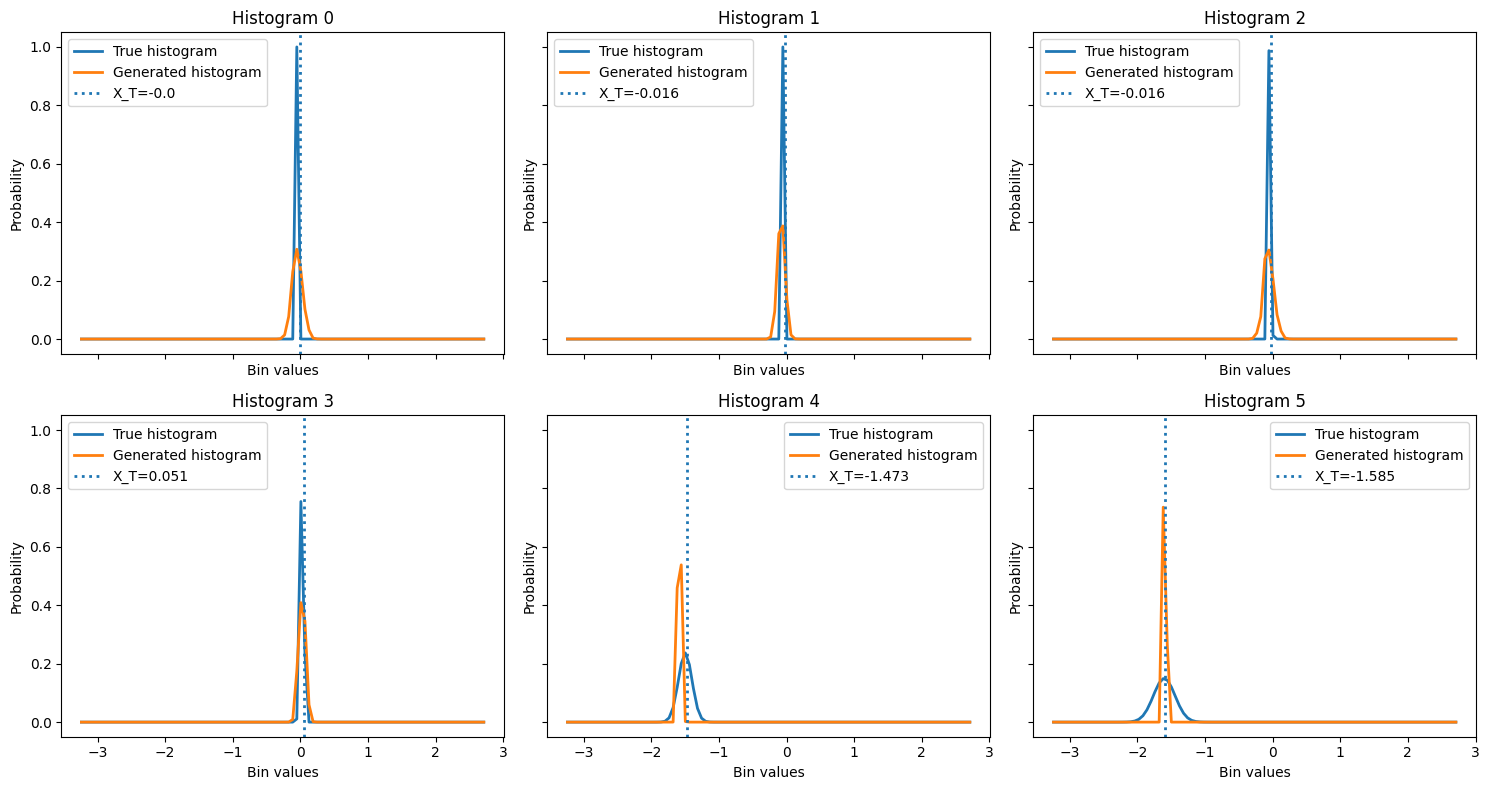

In [11]:
#generated_sample = generated[-1]
#true_sample = pdfs[-1]
#plot_bin_dist(true_sample, generated_sample, bins, Xt[-1])

plot_bin_dist(pdfs, generated, bins, Xt, ncols=3)



# CWGAN BINS PROBABILITIES

In [2]:
# data simulation 
# example
X0_range = (0.0,0.0)
mu_range = (0.0, 0.0)
sigma_range = (0.005, 0.5)
T = 1.0        # Time horizon (1 year)
N = 252        # Number of time steps
J = 100000        # Number of paths to simulate
SEED=42

# --- Run the Simulation ---
sim = DataSimulator(X0_range=X0_range, mu_range=mu_range, sigma_range=sigma_range, 
                            T=T, N=N, n_simulations=J, seed=SEED)

paths = sim.get_paths()
pdfs= sim.get_pdf(n_steps_ahead=10, n_bins=100)
sim.save_configuration('./models/bins/CWGAN_bins_pglobal_v3.json')
pdfs

Bins saved to models\bins\CWGAN_bins_pglobal_v3.json


array([[0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       ...,
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.]], shape=(100000, 100))

In [3]:
mydata, _, _ = prepare_data(pdfs, paths, preprocess="log")

generator_params = {"hidden_dims": [512, 256, 256, 128], "use_batch_norm":False}
critic_params = {"hidden_dims": [512, 256, 256, 128, 64], 'use_layer_norm':True}
conditional_gan = MyCWGAN(max_epoch=100, name='CWGAN_bins_pglobal_v3')
conditional_gan.set_generator(condition_size=paths.shape[1], output_dim=pdfs.shape[1], is_prob = True, **generator_params)
conditional_gan.set_discriminator(input_size=pdfs.shape[1], condition_size=paths.shape[1], **critic_params)
conditional_gan.train(mydata, save_history=True, early_stopping_waiting=100)
conditional_gan.save_models()
stats = conditional_gan.evaluate_error_distribution(mydata, 'CWGAN_error_dist_v3.csv')


Epoch: 0/100, Step: 0, C_loss: 9.3210, G_loss: 0.1834, W_dist: 0.0360, GP: 0.9357
Epoch: 0/100, Step: 500, C_loss: -5.0992, G_loss: 4.6226, W_dist: 7.4625, GP: 0.2363
Epoch: 0/100, Step: 1000, C_loss: -10.1226, G_loss: 6.1332, W_dist: 10.8782, GP: 0.0756
Epoch: 0/100, Step: 1500, C_loss: -13.9790, G_loss: 7.8714, W_dist: 16.1181, GP: 0.2139


c:\Users\matte\LEARNING\MAGISTRALE\QUANTITATIVE FINANCE\TESI\cGAN_code\myCWGAN.py:365: UserWarning: Converting a tensor with requires_grad=True to a scalar may lead to unexpected behavior.
Consider using tensor.detach() first. (Triggered internally at C:\actions-runner\_work\pytorch\pytorch\pytorch\torch\csrc\autograd\generated\python_variable_methods.cpp:836.)
  C_loss_list.append(round(float(C_loss), 4))


Epoch: 0/100, Step: 2000, C_loss: -19.3729, G_loss: 12.1039, W_dist: 21.7018, GP: 0.2329
Epoch: 0/100, Step: 2500, C_loss: -25.0981, G_loss: 12.9191, W_dist: 27.2824, GP: 0.2184
Epoch: 0/100, Step: 3000, C_loss: -33.3191, G_loss: 18.3296, W_dist: 35.1946, GP: 0.1875
Epoch: 1/100, Step: 3500, C_loss: -32.8775, G_loss: 20.9703, W_dist: 36.8245, GP: 0.3947
Epoch: 1/100, Step: 4000, C_loss: -30.4910, G_loss: 21.9796, W_dist: 35.0994, GP: 0.4608
Epoch: 1/100, Step: 4500, C_loss: -30.8086, G_loss: 22.0374, W_dist: 35.9744, GP: 0.5166
Epoch: 1/100, Step: 5000, C_loss: -35.6817, G_loss: 26.5420, W_dist: 40.4543, GP: 0.4773
Epoch: 1/100, Step: 5500, C_loss: -26.2418, G_loss: 25.8122, W_dist: 34.7046, GP: 0.8463
Epoch: 1/100, Step: 6000, C_loss: -37.1729, G_loss: 26.6956, W_dist: 44.5811, GP: 0.7408
Epoch: 2/100, Step: 6500, C_loss: -26.3206, G_loss: 27.2034, W_dist: 39.0134, GP: 1.2693
Epoch: 2/100, Step: 7000, C_loss: -27.3693, G_loss: 28.5142, W_dist: 32.7064, GP: 0.5337
Epoch: 2/100, Step: 7

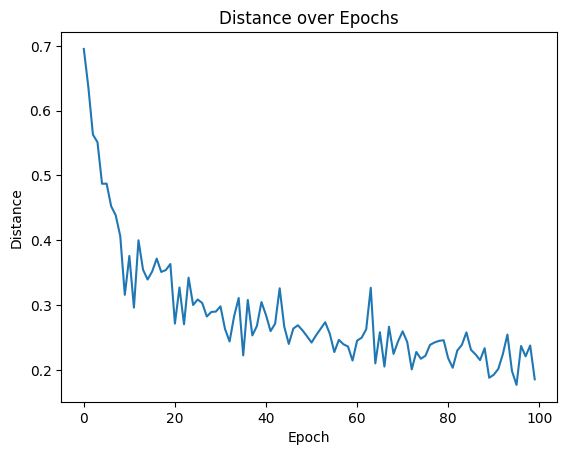

In [4]:
plot_learning_curve('wcgan_generated_vs_true.csv')

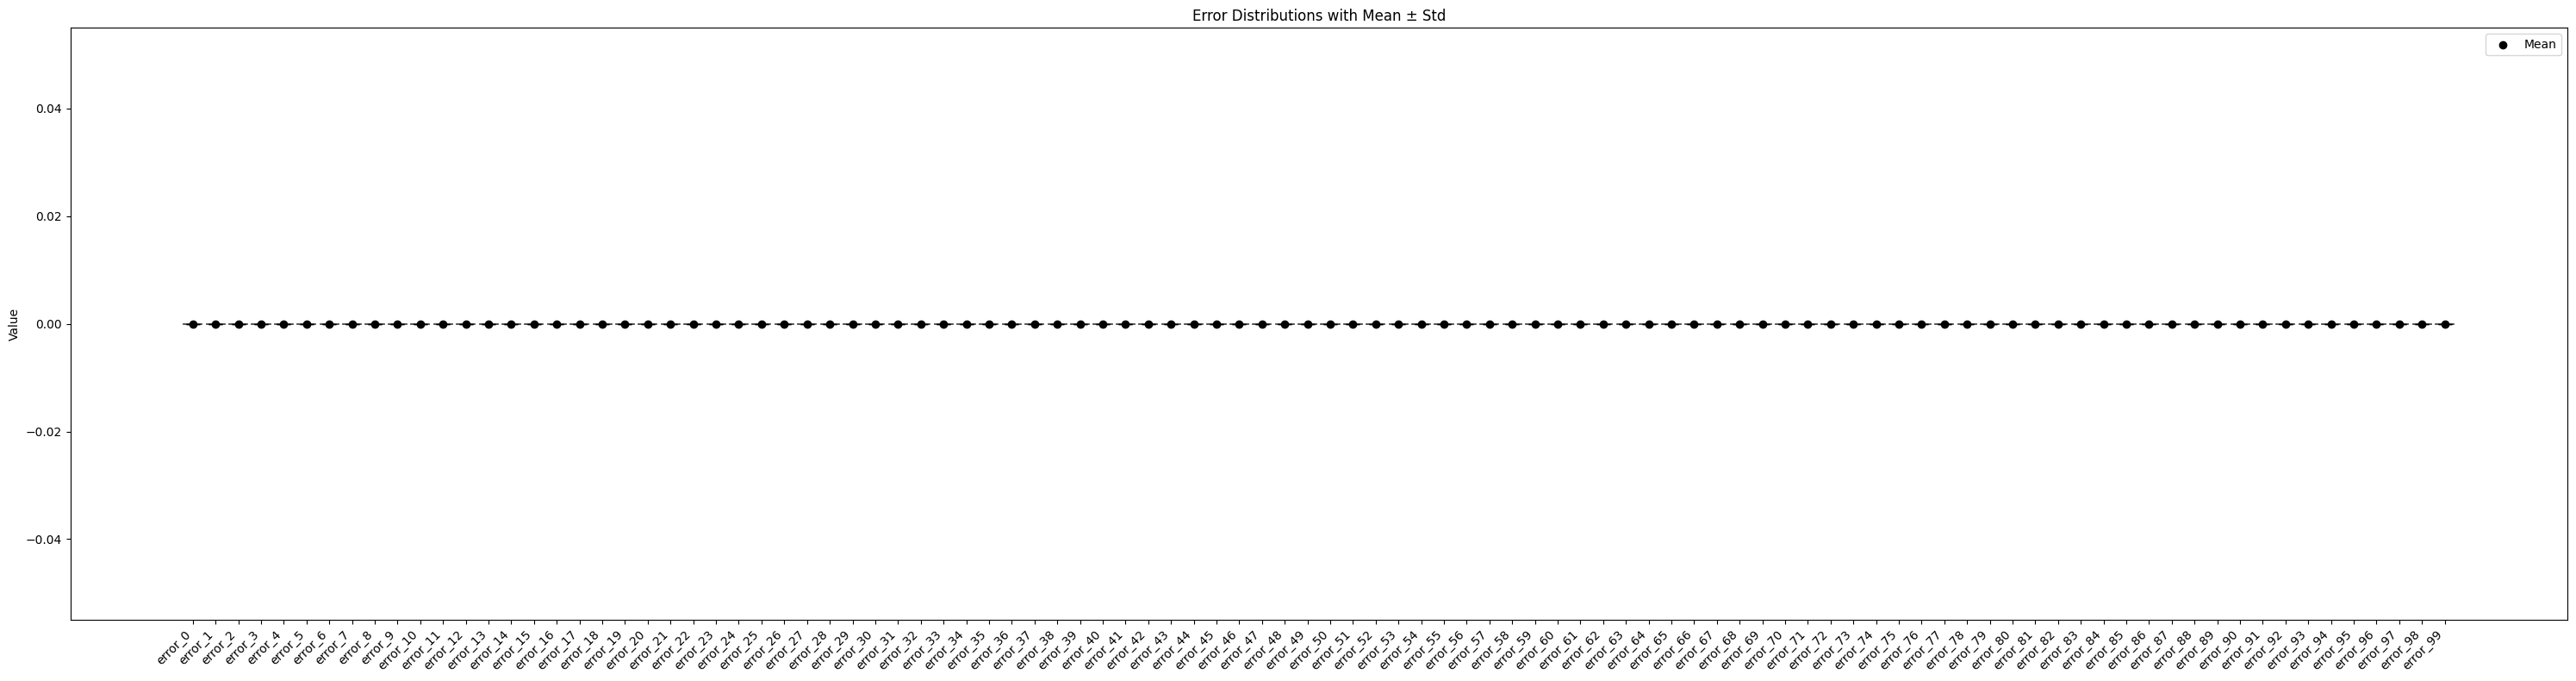

error_0     0.0
error_1     0.0
error_2     0.0
error_3     0.0
error_4     0.0
           ... 
error_95    0.0
error_96    0.0
error_97    0.0
error_98    0.0
error_99    0.0
Length: 100, dtype: float64 
 error_0     0.0
error_1     0.0
error_2     0.0
error_3     0.0
error_4     0.0
           ... 
error_95    0.0
error_96    0.0
error_97    0.0
error_98    0.0
error_99    0.0
Length: 100, dtype: float64 
           mean  std  median  skew  kurtosis  is_zero_test confidence_interval
error_0    0.0  0.0     0.0   0.0       0.0         False          (0.0, 0.0)
error_1    0.0  0.0     0.0   0.0       0.0         False          (0.0, 0.0)
error_2    0.0  0.0     0.0   0.0       0.0         False          (0.0, 0.0)
error_3    0.0  0.0     0.0   0.0       0.0         False          (0.0, 0.0)
error_4    0.0  0.0     0.0   0.0       0.0         False          (0.0, 0.0)
...        ...  ...     ...   ...       ...           ...                 ...
error_95   0.0  0.0     0.0   0.0       0.

In [5]:
means, std, summary = analyze_error_distribution('./data/results/CWGAN_error_dist_v3.csv')
print(means,'\n', std, '\n', summary)

## KS TEST

In [6]:
# data simulation 
# example

X0_range = [0.0, 0.0, 0.0, 0.0, 0.0, 0.0]
mu_range = [0.0, 0.0, 0.0, 0.0, 0.0, 0.0]
sigma_range = [0.001, 0.01, 0.05, 0.1, 0.5, 0.8]
T = 1.0        # Time horizon (1 year)
N = 252        # Number of time steps
J = 6       # Number of paths to simulate
SEED=2

#generate
val = DataSimulator(X0_range=X0_range, mu_range=mu_range, sigma_range=sigma_range, 
                            T=T, N=N, n_simulations=J, seed=SEED)

val.load_configuration('./models/bins/CWGAN_bins_pglobal_v3.json')
paths = val.get_paths()
pdfs = val.get_pdf(n_steps_ahead=10)
Xt = val.X_T
bins = val.bins



Bins loaded from models\bins\CWGAN_bins_pglobal_v3.json
Loaded 101 bins


In [7]:
conditional_gan = MyCGAN(max_epoch=100, name='CWGAN_bins_pglobal_v3')
conditional_gan.load_models()

CGAN config loaded from ./models\CWGAN_bins_pglobal_v3_config.json
Generator loaded from ./models\CWGAN_bins_pglobal_v3_generator.pth
Architecture: MyGenerator
Parameters: {'latent_size': 252, 'condition_size': 253, 'output_dim': 100, 'hidden_dims': [512, 256, 256, 128], 'is_prob': True, 'use_batch_norm': False, 'activation': 'relu', 'dropout': 0.0}
Discriminator loaded from ./models\CWGAN_bins_pglobal_v3_discriminator.pth
Architecture: MyDiscriminator
Parameters: {'input_size': 100, 'condition_size': 253, 'output_dim': 1, 'hidden_dims': [512, 256, 256, 128, 64], 'use_layer_norm': True, 'activation': 'leaky_relu', 'dropout': 0.0}


In [8]:

mydata, mean, std = prepare_data(pdfs, paths, preprocess='log')
preds, _ = conditional_gan.generate(mydata)

generated = np.exp(preds)
p_values = []
for i, row in enumerate(pdfs):
    _, p_value = ks_test_gan_cdf(generated[i], row)
    p_values.append(p_value)

test_df = pd.DataFrame({'p_values':p_values})
test_df


,p_values
0,1.000000e+00
1,3.413671e-01
2,3.503612e-02
3,9.741964e-01
4,3.537367e-12
5,3.428343e-25


In [9]:
test_h0 = test_df[test_df['p_values']>0.01]
print(len(test_h0)/len(test_df))
test_h0

0.6666666666666666


,p_values
0,1.000000
1,0.341367
2,0.035036
3,0.974196


In [10]:
Xt

array([-1.58906936e-04, -1.62955883e-02, -1.64102985e-02,  5.13571998e-02,
       -1.47264368e+00, -1.58450926e+00])

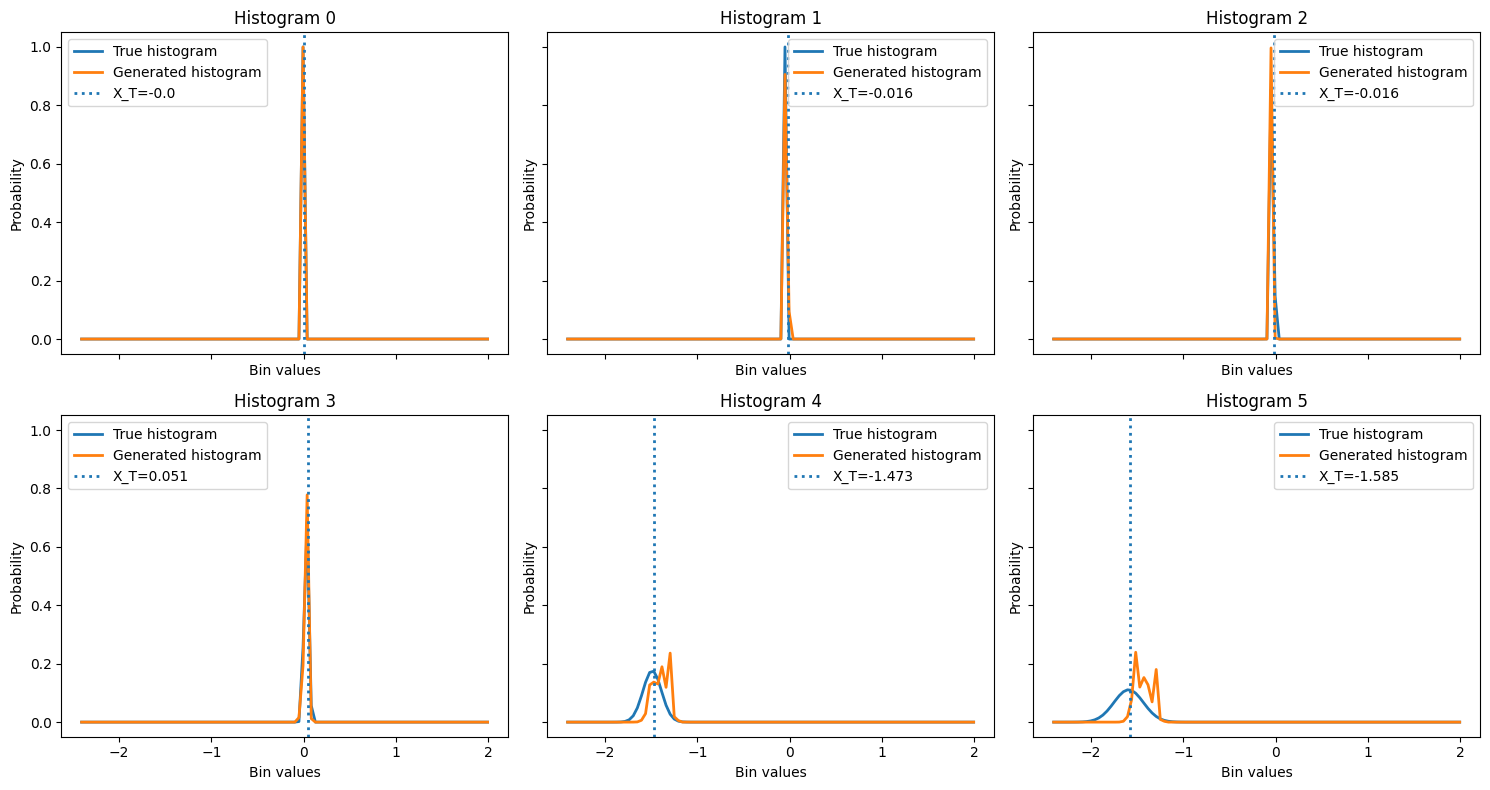

In [11]:
#generated_sample = generated[-1]
#true_sample = pdfs[-1]
#plot_bin_dist(true_sample, generated_sample, bins, Xt[-1])

plot_bin_dist(pdfs, generated, bins, Xt, ncols=3)

